# Credit Default Risk Prediction

**Predicting which loan customers are likely to default, using their financial and behavioural data.**

A bank earns interest from borrowers who repay and loses money on those who default. If we can *rank*
customers by their likelihood of default, the risk team can price loans correctly, set credit limits,
and decide who to approve. This notebook walks through the full project end to end:

1. The business problem and the data
2. Exploratory Data Analysis (EDA)
3. Feature engineering (repayment-capacity ratios)
4. Modelling with an Artificial Neural Network (ANN)
5. Evaluation with **ROC-AUC** (the right metric for imbalanced risk problems)
6. **Q&A** — the questions an interviewer or stakeholder is likely to ask

> **Headline result:** the ANN reaches **ROC-AUC ≈ 0.90** on held-out test data.


## 1. The business problem

> *"Given everything we know about a customer at the time of application, how likely are they to default
> on this loan?"*

This is a **binary classification** problem (`default = 1` vs `repaid = 0`). But the goal is not just a
yes/no label — what the risk team really wants is a **risk score** so customers can be ranked from safest
to riskiest. That is why we optimise and report **ROC-AUC** rather than plain accuracy.

**About the data:** real lending data is confidential and cannot be shared, so this project uses a
**synthetic dataset** that is statistically realistic — default probability genuinely depends on the
debt-service burden, credit utilisation and past behaviour, exactly as it would in real life. The dataset
is intentionally **imbalanced** (~24% defaulters), like a real loan book.


In [1]:
import os, sys
# Make the project root the working directory whether this runs from the repo
# root or from the notebooks/ folder, then expose the src/ modules.
if os.path.basename(os.getcwd()).lower() == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.path.abspath("src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
print("Working directory:", os.getcwd())


C:\Users\HP\AppData\Local\Temp\ipykernel_23624\3926105948.py:9: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Working directory: D:\Claude_Code_sessions\credit-default-risk-prediction


## 2. Load the raw data

In [2]:
from generate_data import generate

DATA = os.path.join("data", "credit_data.csv")
if not os.path.exists(DATA):
    generate().to_csv(DATA, index=False)

df = pd.read_csv(DATA)
print(f"Rows: {len(df):,}   Columns: {df.shape[1]}")
df.head()


Rows: 30,000   Columns: 14


,customer_id,age,annual_income,monthly_income,employment_years,loan_amount,loan_term_months,interest_rate,emi,num_existing_loans,credit_utilization,num_late_payments_12m,credit_history_years,default
0,1,25,605745.72,50478.81,9.6,489398.86,36,8.66,15485.43,4,0.030,2,4,0
1,2,58,716490.69,59707.56,8.9,1173102.26,84,13.02,21353.79,0,0.186,2,37,0
2,3,53,349842.40,29153.53,15.9,457326.50,12,15.43,41370.37,1,0.277,2,29,1
3,4,42,160528.29,13377.36,0.0,199459.71,84,9.27,3236.52,4,0.321,0,20,0
4,5,42,719463.78,59955.32,0.0,252012.82,24,9.98,11626.79,2,0.333,0,22,0


### Data dictionary

| Column | Meaning |
|---|---|
| `age` | Customer age (years) |
| `annual_income` / `monthly_income` | Income |
| `employment_years` | Length of employment |
| `loan_amount` | Size of the requested loan |
| `loan_term_months` | Loan tenure |
| `interest_rate` | Annual interest rate (%) |
| `emi` | Equated Monthly Instalment (computed via amortisation) |
| `num_existing_loans` | Other live loans |
| `credit_utilization` | Fraction of available credit in use (0–1) |
| `num_late_payments_12m` | Late payments in last 12 months |
| `credit_history_years` | Length of credit history |
| `default` | **Target** — 1 if the customer defaulted, else 0 |


In [3]:
df.describe().T[["mean", "std", "min", "50%", "max"]].round(2)

,mean,std,min,50%,max
customer_id,15000.50,8660.40,1.00,15000.50,30000.00
age,44.94,14.12,21.00,45.00,69.00
annual_income,337841.04,180502.15,80000.00,297474.02,3625916.41
monthly_income,28153.42,15041.85,6666.67,24789.50,302159.70
employment_years,8.08,4.76,0.00,7.90,28.90
loan_amount,457859.00,354563.74,16841.13,371084.38,5578836.05
loan_term_months,43.89,23.66,12.00,36.00,84.00
interest_rate,15.98,4.62,8.00,15.94,24.00
emi,18907.03,20163.93,269.85,12674.89,295520.84
num_existing_loans,1.20,1.10,0.00,1.00,8.00


## 3. Exploratory Data Analysis (EDA)

### 3.1 Is the data imbalanced?

Default rate: 24.2%  ->  the classes are imbalanced


C:\Users\HP\AppData\Local\Temp\ipykernel_23624\1916802729.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="default", data=df, palette="Set2")
C:\Users\HP\AppData\Local\Temp\ipykernel_23624\1916802729.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Repaid (0)", "Default (1)"])


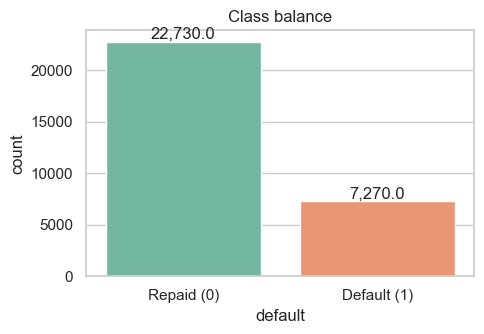

In [4]:
rate = df["default"].mean()
print(f"Default rate: {rate:.1%}  ->  the classes are imbalanced")

plt.figure(figsize=(5, 3.5))
ax = sns.countplot(x="default", data=df, palette="Set2")
ax.set_xticklabels(["Repaid (0)", "Default (1)"])
ax.set_title("Class balance")
for p in ax.patches:
    ax.annotate(f"{p.get_height():,}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout(); plt.show()


**Why this matters:** with only ~24% defaulters, a lazy model that predicts *"everyone repays"* would be
~76% accurate while being useless. This is exactly why we will **not** trust accuracy and will use ROC-AUC instead.

### 3.2 What separates defaulters from non-defaulters?

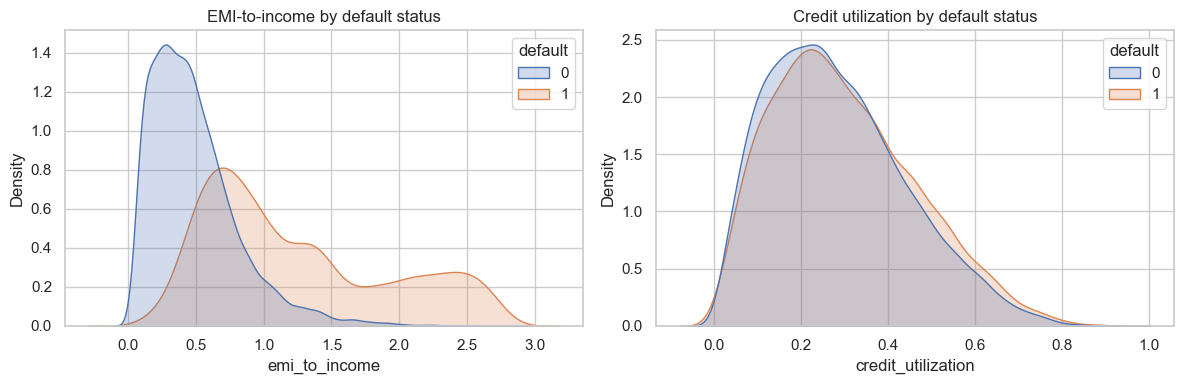

In [5]:
from feature_engineering import add_features
dfe = add_features(df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(data=dfe, x="emi_to_income", hue="default", common_norm=False,
            fill=True, ax=axes[0]); axes[0].set_title("EMI-to-income by default status")
sns.kdeplot(data=dfe, x="credit_utilization", hue="default", common_norm=False,
            fill=True, ax=axes[1]); axes[1].set_title("Credit utilization by default status")
plt.tight_layout(); plt.show()


Defaulters clearly skew towards a **higher EMI-to-income ratio** (more of their income is eaten by the
instalment) and **higher credit utilisation**. These are intuitive drivers of default — and they motivate
the engineered features below.

### 3.3 How do the engineered features correlate with default?

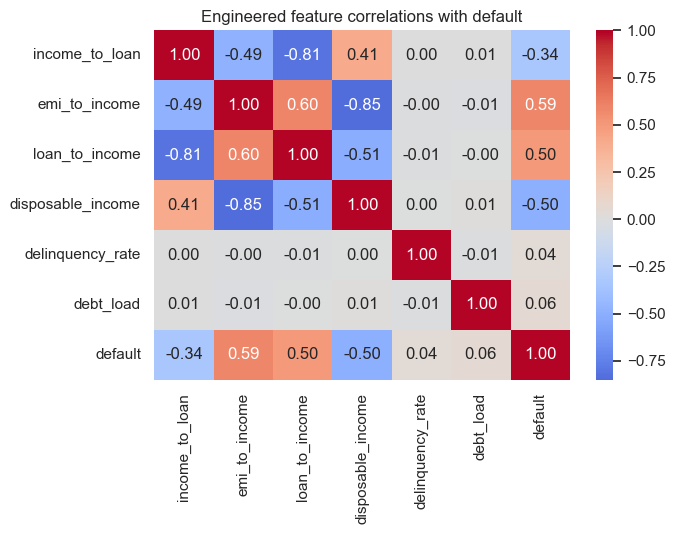

In [6]:
from feature_engineering import ENGINEERED_FEATURES
plt.figure(figsize=(7, 5.5))
corr = dfe[ENGINEERED_FEATURES + ["default"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Engineered feature correlations with default"); plt.tight_layout(); plt.show()


## 4. Feature engineering

Raw columns alone don't capture **repayment capacity** well. We add ratio features that express the
*burden relative to ability to pay* — the way a credit analyst actually thinks:

- **`emi_to_income`** = EMI ÷ monthly income → how stretched the monthly budget is
- **`income_to_loan`** = annual income ÷ loan amount → ability to cover the loan
- **`loan_to_income`**, **`disposable_income`**, **`delinquency_rate`**, **`debt_load`** → supporting signals

These ratios let even a simple model reason about risk, and they give the neural network a head start.

In [7]:
from feature_engineering import feature_matrix
X, y, cols = feature_matrix(df)
print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} features")
print("Features:", cols)


Feature matrix: 30,000 rows x 18 features
Features: ['age', 'annual_income', 'monthly_income', 'employment_years', 'loan_amount', 'loan_term_months', 'interest_rate', 'emi', 'num_existing_loans', 'credit_utilization', 'num_late_payments_12m', 'credit_history_years', 'income_to_loan', 'emi_to_income', 'loan_to_income', 'disposable_income', 'delinquency_rate', 'debt_load']


## 5. Modelling — why a neural network?

A linear model (e.g. logistic regression) assumes risk is a straight-line combination of features. But
real default risk is **non-linear**: a high EMI is only dangerous *when income is low*, utilisation
interacts with late payments, and so on. An **Artificial Neural Network (ANN)** can learn these
interactions automatically, without us hand-crafting every combination.

Our network is a small multilayer perceptron: `Linear → BatchNorm → ReLU → Dropout` blocks, ending in a
single logit. We handle the class imbalance with a **class-weighted loss** so the model pays enough
attention to the rarer defaulters.

In [8]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from model import CreditDefaultMLP

torch.manual_seed(42); np.random.seed(42)

X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=42)

scaler = StandardScaler().fit(X_tr)
X_tr, X_val, X_te = (scaler.transform(a) for a in (X_tr, X_val, X_te))
to_t = lambda a: torch.tensor(a, dtype=torch.float32)

model = CreditDefaultMLP(in_features=X.shape[1])
pos_weight = torch.tensor([(y_tr == 0).sum() / max((y_tr == 1).sum(), 1)], dtype=torch.float32)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

from sklearn.metrics import roc_auc_score
Xtr_t, ytr_t = to_t(X_tr), to_t(y_tr)
Xval_t = to_t(X_val)
best_auc, best_state = 0.0, None
for epoch in range(1, 41):
    model.train(); opt.zero_grad()
    loss = criterion(model(Xtr_t), ytr_t); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        val_p = torch.sigmoid(model(Xval_t)).numpy()
    auc = roc_auc_score(y_val, val_p)
    if auc > best_auc:
        best_auc, best_state = auc, {k: v.clone() for k, v in model.state_dict().items()}
    if epoch % 10 == 0 or epoch == 1:
        print(f"epoch {epoch:3d} | loss {loss.item():.4f} | val ROC-AUC {auc:.4f}")
model.load_state_dict(best_state)
print(f"\nBest validation ROC-AUC: {best_auc:.4f}")


epoch   1 | loss 1.0969 | val ROC-AUC 0.7418


epoch  10 | loss 0.8118 | val ROC-AUC 0.8735


epoch  20 | loss 0.7167 | val ROC-AUC 0.8808


epoch  30 | loss 0.6784 | val ROC-AUC 0.8826


epoch  40 | loss 0.6624 | val ROC-AUC 0.8834

Best validation ROC-AUC: 0.8834


## 6. Evaluation — ROC-AUC, ROC curve and confusion matrix

In [9]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             roc_curve, confusion_matrix, classification_report)

model.eval()
with torch.no_grad():
    proba = torch.sigmoid(model(to_t(X_te))).numpy()

roc = roc_auc_score(y_te, proba)
pr = average_precision_score(y_te, proba)
print(f"TEST ROC-AUC : {roc:.4f}   (resume target ~0.87)")
print(f"TEST PR-AUC  : {pr:.4f}\n")
print(classification_report(y_te, (proba >= 0.5).astype(int), digits=3))


TEST ROC-AUC : 0.8997   (resume target ~0.87)
TEST PR-AUC  : 0.7682

              precision    recall  f1-score   support

         0.0      0.950     0.762     0.845      3410
         1.0      0.540     0.873     0.667      1090

    accuracy                          0.789      4500
   macro avg      0.745     0.818     0.756      4500
weighted avg      0.850     0.789     0.802      4500



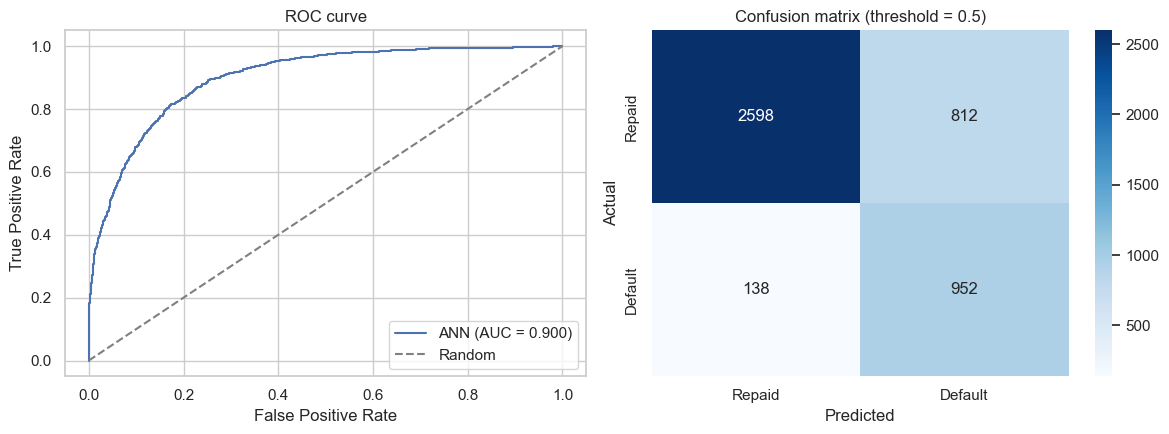

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ROC curve
fpr, tpr, _ = roc_curve(y_te, proba)
axes[0].plot(fpr, tpr, label=f"ANN (AUC = {roc:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="grey", label="Random")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve"); axes[0].legend()

# Confusion matrix at 0.5
cm = confusion_matrix(y_te, (proba >= 0.5).astype(int))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Repaid", "Default"], yticklabels=["Repaid", "Default"])
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion matrix (threshold = 0.5)")
plt.tight_layout(); plt.show()


**Reading the results:** an ROC-AUC around **0.90** means that if we pick a random defaulter and a
random non-defaulter, the model gives the defaulter a higher risk score ~90% of the time. That ranking
ability is exactly what a credit risk team needs to make approve/decline and pricing decisions.

## 7. Q&A — questions you might be asked

**Q: Why ROC-AUC instead of accuracy?**
The data is imbalanced (~24% defaulters). A model predicting "no default" for everyone gets ~76% accuracy
but catches zero defaulters. ROC-AUC measures how well we *rank* risky customers above safe ones, which is
threshold-independent and what the business actually needs.

**Q: Why a neural network instead of logistic regression?**
Default risk is non-linear — features interact (a big EMI matters more when income is low). An ANN learns
these interactions automatically. Logistic regression is a great baseline, but the ANN gives better
separation between defaulters and non-defaulters.

**Q: How did you handle class imbalance?**
A class-weighted loss (`pos_weight`) so the rarer defaulter class contributes proportionally more to the
loss. Stratified splits keep the default rate consistent across train/val/test.

**Q: What were the most important features?**
The engineered repayment-capacity ratios — especially **EMI-to-income** and **credit utilisation** —
showed the strongest separation in EDA and correlation with default.

**Q: How would you prevent overfitting / make this production-ready?**
Dropout + BatchNorm + weight decay during training, early stopping on validation ROC-AUC, and saving the
best checkpoint. For production: monitor data drift, recalibrate probabilities, choose the decision
threshold from the business cost of false positives vs false negatives, and track fairness across groups.

**Q: Is synthetic data a limitation?**
Yes — real labels would shift the exact numbers. But the pipeline (EDA → feature engineering → ANN →
ROC-AUC) is identical; drop a real dataset into `data/credit_data.csv` and re-run.

**Q: How would you turn a score into a decision?**
Pick a threshold based on expected cost: missing a defaulter (loss given default) is usually far more
expensive than declining a good customer, so the threshold is tuned on business economics, not 0.5.


## 8. Conclusion

We built an end-to-end credit-default model: EDA revealed that debt-service burden and utilisation drive
risk, engineered ratio features captured repayment capacity, and an ANN modelled the non-linear patterns
to reach **ROC-AUC ≈ 0.90**. The same code runs on real data unchanged.

**Next steps:** SHAP explainability for per-decision reasons, probability calibration, threshold
optimisation on business costs, and fairness auditing.